Using device: cuda


Epoch 1/50: 100%|██████████| 468/468 [00:21<00:00, 22.05it/s, D_loss=0.5614, G_loss=0.6961]


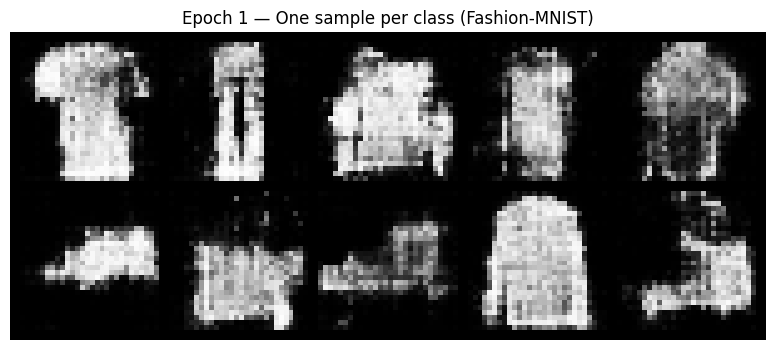

Epoch 5/50: 100%|██████████| 468/468 [00:21<00:00, 21.63it/s, D_loss=0.3518, G_loss=1.5245]


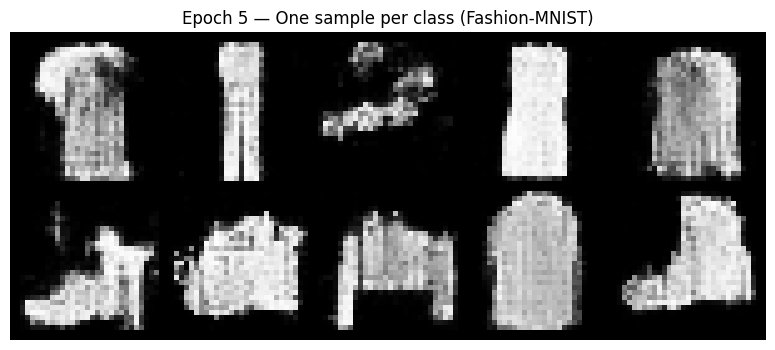

Epoch 10/50: 100%|██████████| 468/468 [00:21<00:00, 21.58it/s, D_loss=0.3929, G_loss=1.3363]


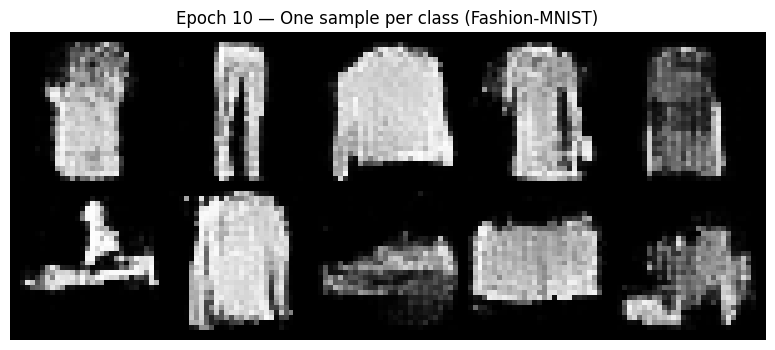

Epoch 15/50: 100%|██████████| 468/468 [00:23<00:00, 20.21it/s, D_loss=0.2348, G_loss=1.9671]


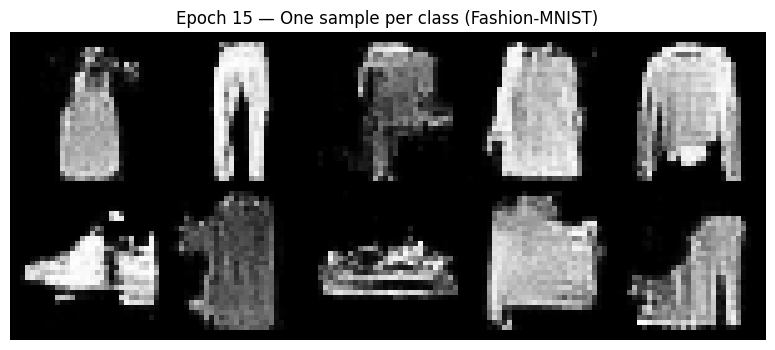

Epoch 20/50: 100%|██████████| 468/468 [00:22<00:00, 20.52it/s, D_loss=0.3483, G_loss=2.3665]


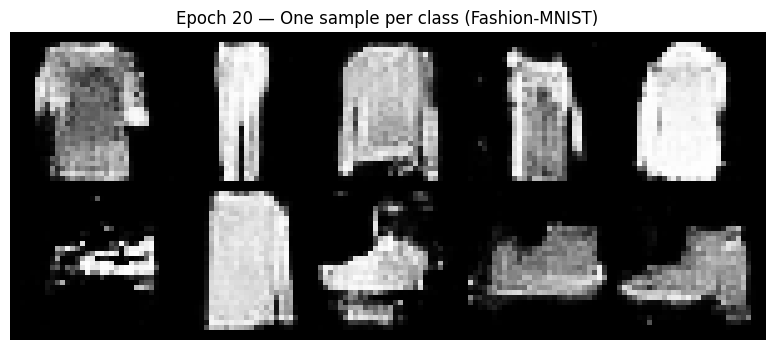

Epoch 25/50: 100%|██████████| 468/468 [00:22<00:00, 20.49it/s, D_loss=0.2284, G_loss=1.8128]


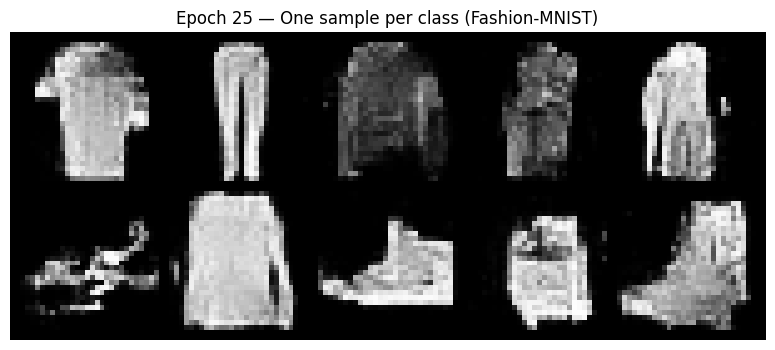

Epoch 30/50: 100%|██████████| 468/468 [00:23<00:00, 20.28it/s, D_loss=0.2831, G_loss=1.6116]


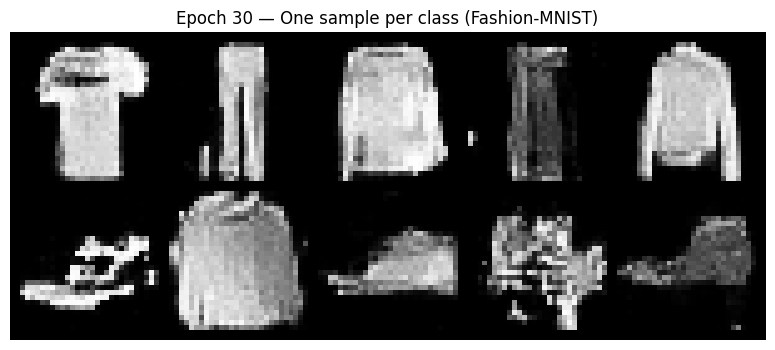

Epoch 35/50: 100%|██████████| 468/468 [00:22<00:00, 20.67it/s, D_loss=0.3167, G_loss=1.1079]


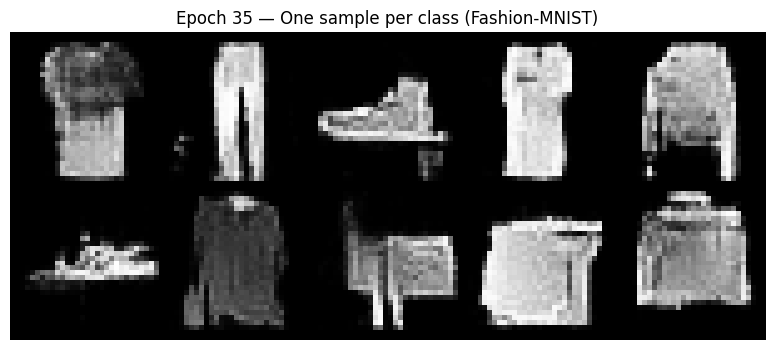

Epoch 40/50: 100%|██████████| 468/468 [00:22<00:00, 20.90it/s, D_loss=0.3200, G_loss=1.8238]


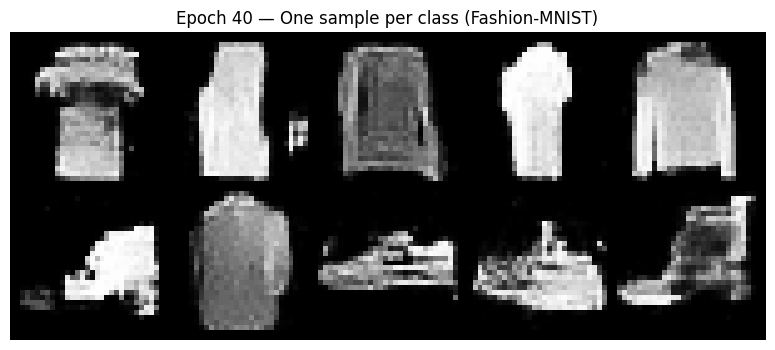

Epoch 45/50: 100%|██████████| 468/468 [00:24<00:00, 19.46it/s, D_loss=0.2233, G_loss=2.1901]


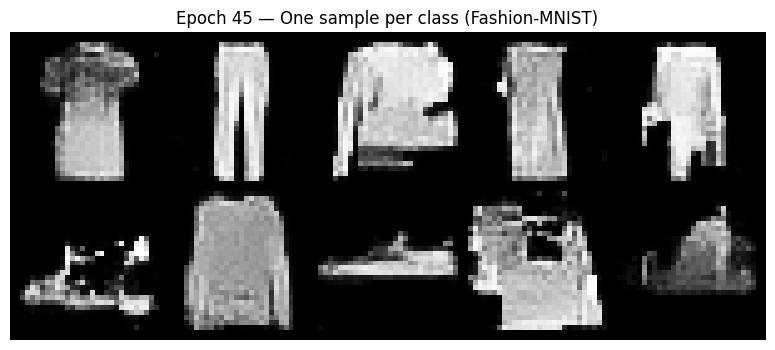

Epoch 50/50: 100%|██████████| 468/468 [00:25<00:00, 18.34it/s, D_loss=0.3248, G_loss=1.4128]


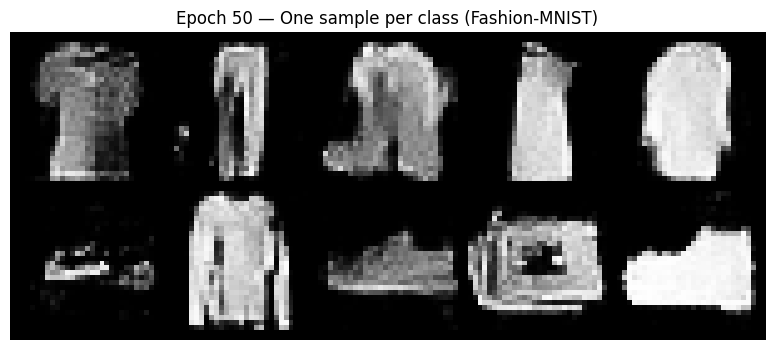

Training finished!


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

batch_size = 128
z_dim = 100
num_classes = 10
img_size = 28
channels = 1
lr = 0.0002
betas = (0.5, 0.999)
num_epochs = 50

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# Conditional generator
class Generator(nn.Module):
    def __init__(self, z_dim=100, num_classes=10, img_size=28, channels=1):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, z_dim)
        self.init_size = img_size // 4  # 7

        self.l1 = nn.Sequential(
            nn.Linear(z_dim * 2, 128 * self.init_size ** 2),
            nn.BatchNorm1d(128 * self.init_size ** 2),
            nn.ReLU(inplace=True),
        )

        self.conv_blocks = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, channels, 4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, z, labels):
        label_emb = self.label_emb(labels)
        gen_input = torch.cat((z, label_emb), dim=1)
        out = self.l1(gen_input)
        out = out.view(out.size(0), 128, self.init_size, self.init_size)
        return self.conv_blocks(out)


# Conditiona Discriminator
class Discriminator(nn.Module):
    def __init__(self, img_size=28, channels=1, num_classes=10):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, 1)
        self.img_size = img_size

        self.model = nn.Sequential(
            nn.Conv2d(channels + 1, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128 * (img_size // 4) * (img_size // 4), 1),
        )

    def forward(self, img, labels):
        label_input = self.label_emb(labels).view(-1, 1, 1, 1)
        label_input = label_input.expand(-1, 1, self.img_size, self.img_size)
        x = torch.cat((img, label_input), dim=1)
        return self.model(x)


G = Generator(z_dim, num_classes, img_size, channels).to(device)
D = Discriminator(img_size, channels, num_classes).to(device)

optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=betas)
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=betas)

criterion = nn.BCEWithLogitsLoss()

# Training
G.train()
D.train()

for epoch in range(num_epochs):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for real_imgs, labels in pbar:
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)
        batch_size = real_imgs.size(0)

        # Train Discriminator
        optimizer_D.zero_grad()

        real_validity = D(real_imgs, labels)
        real_loss = criterion(real_validity, torch.ones(batch_size, 1, device=device))

        z = torch.randn(batch_size, z_dim, device=device)
        fake_imgs = G(z, labels)
        fake_validity = D(fake_imgs.detach(), labels)
        fake_loss = criterion(fake_validity, torch.zeros(batch_size, 1, device=device))

        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()

        z = torch.randn(batch_size, z_dim, device=device)
        fake_imgs = G(z, labels)
        fake_validity = D(fake_imgs, labels)
        g_loss = criterion(fake_validity, torch.ones(batch_size, 1, device=device))
        g_loss.backward()
        optimizer_G.step()

        # Update progress bar
        pbar.set_postfix({
            "D_loss": f"{d_loss.item():.4f}",
            "G_loss": f"{g_loss.item():.4f}"
        })

    # Sample and Visualize
    if (epoch + 1) % 5 == 0 or epoch == 0:
        G.eval()
        with torch.no_grad():
            z = torch.randn(num_classes, z_dim, device=device)
            sample_labels = torch.arange(num_classes, device=device)
            fake_imgs = G(z, sample_labels)
            fake_imgs = fake_imgs * 0.5 + 0.5  # denormalize to [0,1]

            grid = make_grid(fake_imgs, nrow=5, normalize=False)
            plt.figure(figsize=(10, 4))
            plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
            plt.title(f"Epoch {epoch+1} — One sample per class (Fashion-MNIST)")
            plt.axis("off")
            plt.show()
        G.train()

print("Training finished!")

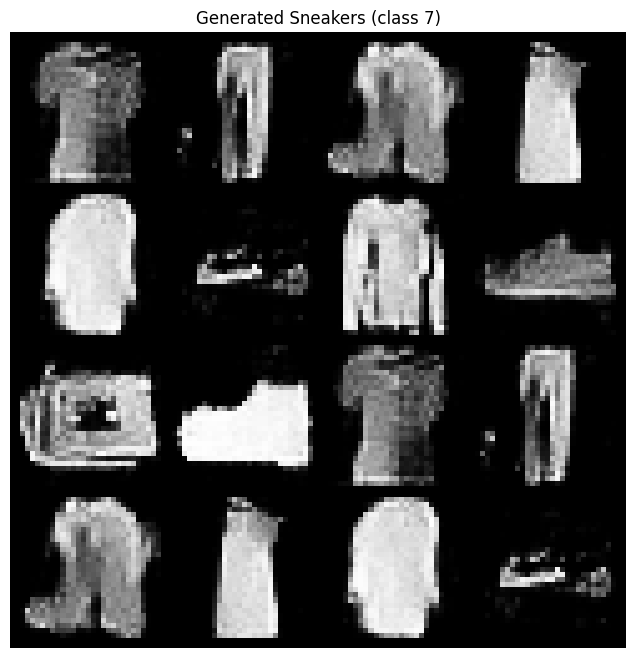

In [9]:
# Example: generate 16 "Sneakers" (class 7)
G.eval()
with torch.no_grad():
    z = torch.randn(16, z_dim, device=device)
    labels=torch.tensor([0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5]).to(device)

    fake = G(z, labels)
    fake = fake * 0.5 + 0.5

    grid = make_grid(fake, nrow=4, normalize=False)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title("Generated Sneakers (class 7)")
    plt.axis("off")
    plt.show()